In [1]:
import pyrpl
from pyrpl import Pyrpl


In [2]:
HOSTNAME= 'qifo-pitaya-1.local'#'192.168.0.157'
PASSWORD = "L!g0bears"

p:Pyrpl = Pyrpl(config='', hostname=HOSTNAME, password=PASSWORD, gui=False)
rp = p.rp

INFO:pyrpl.redpitaya:Correct FPGA image detected, skipping reload
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname qifo-pitaya-1.local.


In [3]:
print(p.networkanalyzer.__doc__)


Using an IQ module, the network analyzer can measure the complex coherent
response between an output and any signal in the redpitaya.

Three example ways on how to use the NetworkAnalyzer:



- Example ::
    p = Pyrpl(...)
    na = p.networkanalyzer

    na.output_direct = "out2"                      # Driving output of the network analyzer
    na.input = "out2"
    na.acbandwidth = 4                             # High pass filtering before demodulation
    na.logscale = True
    na.trace_average = 1
    na.average_per_point = average_per_point
    na.points = points

    na.start_freq = 2e4
    na.stop_freq = 5e5

    # adapt the resolution bandwidth so the q=rbw/frequency ratio stays constant
    na.auto_bandwidth = True
    na.q_factor_min = q_factor_min                # min value of the q=rbw/frequency ratio
    na.rbw = rbw                                  # Starting resolution bandwidth value

    na.amplitude = 0.2
    # adapt output amplitude to keep input around target_dbv a

In [4]:
na = p.networkanalyzer
iq0 = rp.iq0

iq0.setup(
    frequency=2.5e6,       # Center frequency of the bandpass (Hz)
    bandwidth=1.0e3,       # Width of the filter passband (Hz)
    acbandwidth=10e5,      # High-pass filter to remove DC / prevent saturation
    phase=0,               # Nominal phase at the center frequency (degrees)
    gain=2.0,              # Peak gain at center frequency (e.g., 2.0 = +6 dB)
    output_direct='off',   # Turn off internal excitation
    output_signal='output_direct', 
    input='in1'            # Source input signal routing
)

In [5]:

na.output_direct = "out1"                      # Driving output of the network analyzer
na.input = "iq0"
na.acbandwidth = 4                             # High pass filtering before demodulation
na.logscale = True
na.trace_average = 1
na.average_per_point = 1
na.points = 100

na.start_freq = 2e4
na.stop_freq = 5e5

# adapt the resolution bandwidth so the q=rbw/frequency ratio stays constant
#na.auto_bandwidth = True
#na.q_factor_min = 10              # min value of the q=rbw/frequency ratio
#na.rbw = 1                               # Starting resolution bandwidth value

na.amplitude = 0.2
# adapt output amplitude to keep input around target_dbv and avoid saturation
na.auto_amplitude = False
na.target_dbv = -40
na.auto_amp_min = 0.001                      # min value of the amplitude
na.auto_amp_max = 0.2

na.start = 100
na.stop = 1000
freqs = na.frequencies
transfer_func = na.single()                 # complex response values

In [ ]:
bode_fig, bode_ax = plt.subplots(1)



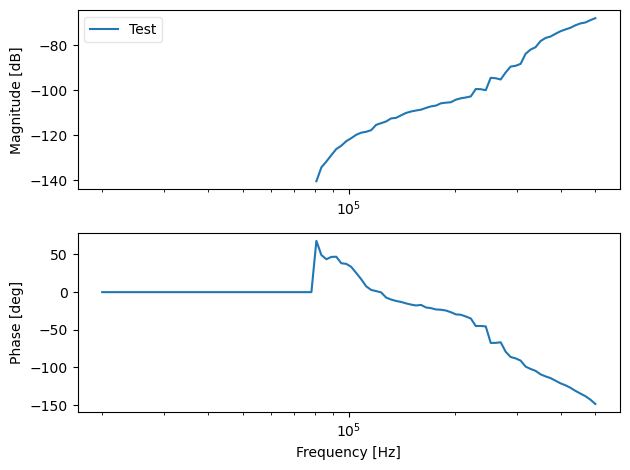

In [ ]:
#plot
from pyrpl.hardware_modules.iir.iir_theory import bodeplot
%matplotlib inline
bodeplot([(freqs, transfer_func, "Test")], xlog=True)
